# MH → SAMC: Two Lines for a Huge Improvement

This notebook shows that SAMC is just MH with a weight correction.
We start with a standard Metropolis-Hastings loop, then add **two lines**
to get SAMC — and show the difference is dramatic.

**Problem:** 2D multimodal energy landscape with many local basins (same as `benchmarks/vs_mh_pt.py`).
At low temperature (T=0.1), MH gets trapped. SAMC escapes.

In [1]:
import math

import matplotlib.pyplot as plt
import torch

from illuma_samc import SAMCWeights
from illuma_samc.problems.multimodal_2d import energy_fn

## Setup

Same energy function, same proposal, same temperature, same number of steps.

In [2]:
# Settings aligned with benchmarks/vs_mh_pt.py (2D multimodal)
T = 0.1  # low temperature — makes MH struggle
N_STEPS = 500_000  # same as benchmark
PROPOSAL_STD = 0.05  # same as benchmark
SEED = 42


# Energy wrapper (scalar in, scalar out)
def E(x):
    e, in_region = energy_fn(x)
    return float(e), bool(in_region)

## Standard MH

This is the baseline. Nothing fancy — propose, accept/reject, repeat.

In [3]:
torch.manual_seed(SEED)
x = torch.zeros(2)
fx, _ = E(x)

mh_samples = []
mh_energies = []
mh_accept = 0

for t in range(1, N_STEPS + 1):
    x_new = x + PROPOSAL_STD * torch.randn(2)
    fy, in_region = E(x_new)

    log_r = (-fy + fx) / T

    if in_region and (log_r > 0 or math.log(torch.rand(1).item() + 1e-300) < log_r):
        x, fx = x_new.clone(), fy
        mh_accept += 1

    mh_energies.append(fx)
    if t % 100 == 0:
        mh_samples.append(x.clone())

mh_samples = torch.stack(mh_samples)
mh_energies = torch.tensor(mh_energies)
print(f"MH  — accept: {mh_accept / N_STEPS:.3f}, best E: {min(mh_energies):.3f}")

MH  — accept: 0.047, best E: -8.125


## MH + SAMC (add two lines)

Same loop. Same proposal. Same temperature. Two additions marked with `# ← SAMC`.

In [4]:
torch.manual_seed(SEED)
x = torch.zeros(2)
fx, _ = E(x)

wm = SAMCWeights()  # ← SAMC: zero config — bins auto-created on first energy

samc_samples = []
samc_energies = []
samc_accept = 0

for t in range(1, N_STEPS + 1):
    x_new = x + PROPOSAL_STD * torch.randn(2)
    fy, in_region = E(x_new)

    log_r = (-fy + fx) / T + wm.correction(fx, fy)  # ← SAMC: add correction

    if in_region and (log_r > 0 or math.log(torch.rand(1).item() + 1e-300) < log_r):
        x, fx = x_new.clone(), fy
        samc_accept += 1

    wm.step(t, fx)  # ← SAMC: update weights
    samc_energies.append(fx)
    if t % 100 == 0:
        samc_samples.append(x.clone())

samc_samples = torch.stack(samc_samples)
samc_energies = torch.tensor(samc_energies)
print(f"SAMC — accept: {samc_accept / N_STEPS:.3f}, best E: {min(samc_energies):.3f}")
print(f"       bins visited: {(wm.counts > 0).sum().item():.0f}, flatness: {wm.flatness():.3f}")

SAMC — accept: 0.288, best E: -8.125
       bins visited: 17, flatness: 0.980


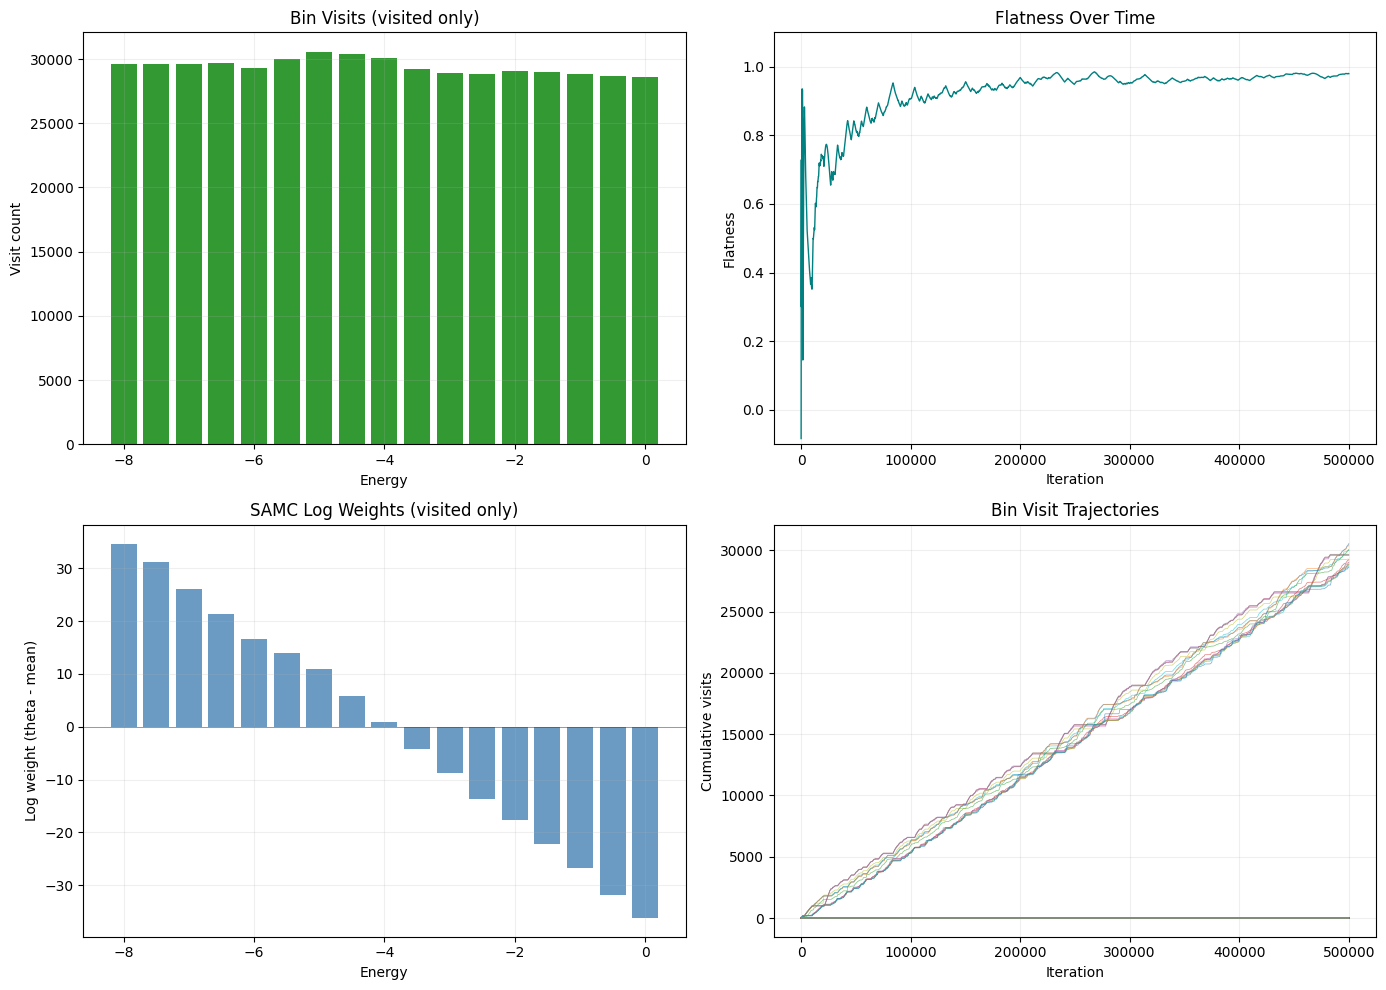

In [5]:
_ = wm.plot_diagnostics()

## Diagnostics

### 1. Energy Traces

MH flatlines (trapped). SAMC oscillates across the full energy range (mixing).

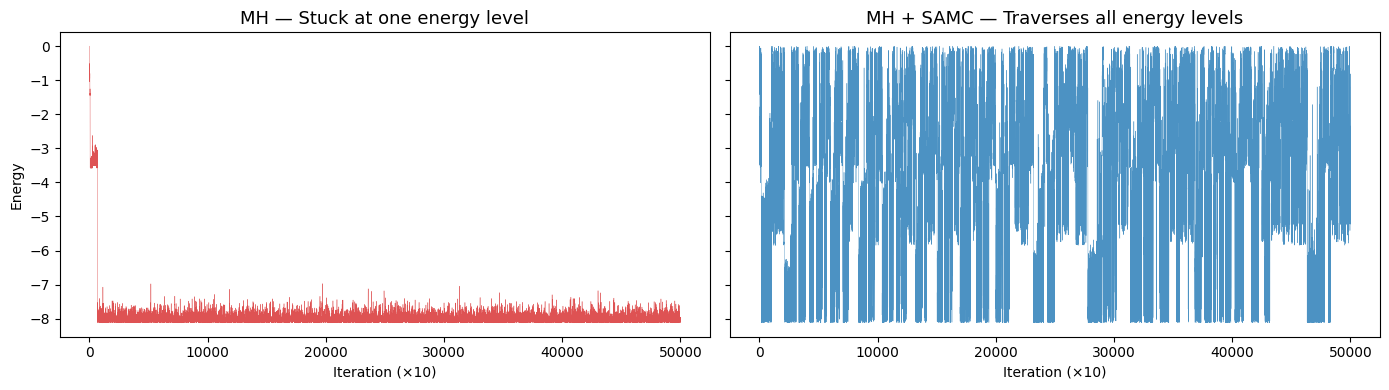

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

axes[0].plot(mh_energies[::10].numpy(), lw=0.3, alpha=0.8, color="tab:red")
axes[0].set_title("MH — Stuck at one energy level", fontsize=13)
axes[0].set_xlabel("Iteration (×10)")
axes[0].set_ylabel("Energy")

axes[1].plot(samc_energies[::10].numpy(), lw=0.3, alpha=0.8, color="tab:blue")
axes[1].set_title("MH + SAMC — Traverses all energy levels", fontsize=13)
axes[1].set_xlabel("Iteration (×10)")

plt.tight_layout()
plt.show()

### 2. Sample Traces in Domain Space

MH explores a tiny region. SAMC covers the full domain.

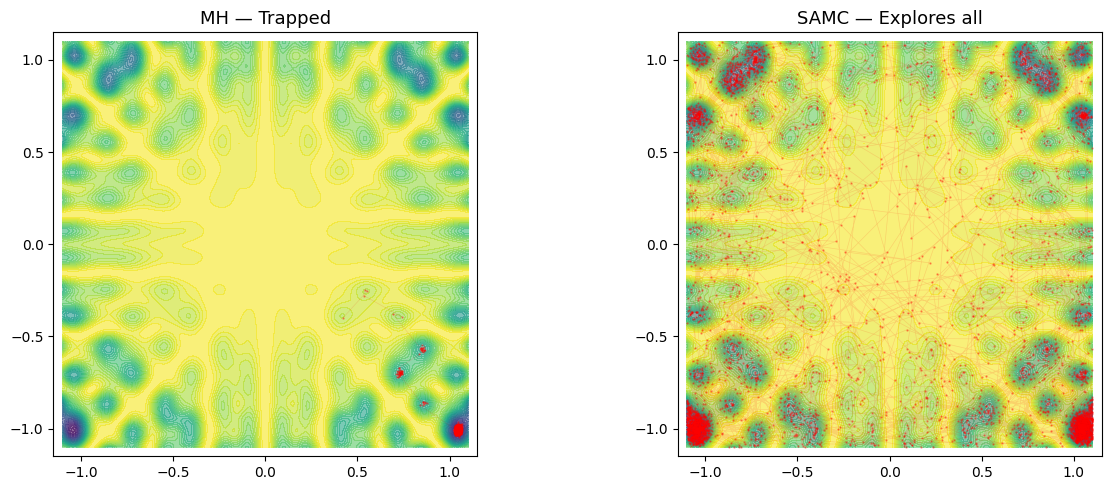

In [7]:
# Energy landscape background
grid = torch.linspace(-1.1, 1.1, 200)
X, Y = torch.meshgrid(grid, grid, indexing="ij")
Z_flat = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)
E_grid, _ = energy_fn(Z_flat)
E_grid = E_grid.reshape(200, 200).numpy()
X_np, Y_np = X.numpy(), Y.numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, samples, title in [
    (axes[0], mh_samples, "MH — Trapped"),
    (axes[1], samc_samples, "SAMC — Explores all"),
]:
    s = samples.numpy()
    n = len(s)
    step = max(1, n // 3000)
    sx, sy = s[::step, 0], s[::step, 1]

    ax.contourf(X_np, Y_np, E_grid, levels=40, cmap="viridis", alpha=0.6)
    ax.plot(sx, sy, color="red", alpha=0.12, linewidth=0.5, zorder=2)
    ax.scatter(sx, sy, c="red", s=0.5, alpha=0.35, zorder=3)

    ax.set_title(title, fontsize=13)
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

### 3. Flat Density in Energy Space

SAMC's whole point: visit every energy level uniformly.

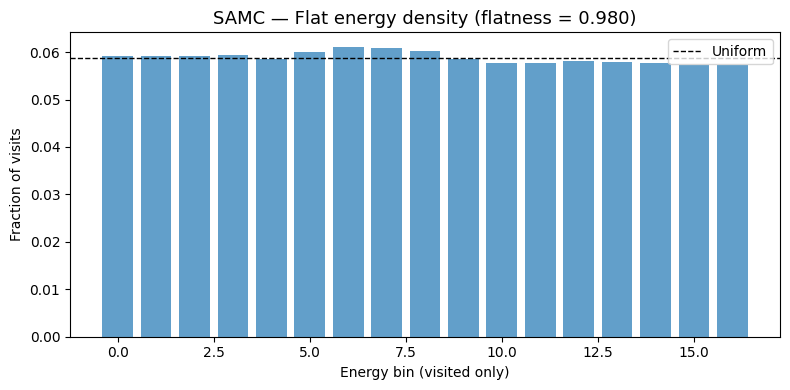

Bins visited: 17
Flatness: 0.980 (1.0 = perfect)


In [8]:
# SAMC bin visits (visited bins only)
samc_counts_np = wm.counts.numpy()
visited_mask = samc_counts_np > 0
visited_counts = samc_counts_np[visited_mask]
visited_counts = visited_counts / max(visited_counts.sum(), 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(visited_counts)), visited_counts, color="tab:blue", alpha=0.7)
ax.axhline(1.0 / len(visited_counts), color="k", ls="--", lw=1, label="Uniform")
ax.set_title(f"SAMC — Flat energy density (flatness = {wm.flatness():.3f})", fontsize=13)
ax.set_xlabel("Energy bin (visited only)")
ax.set_ylabel("Fraction of visits")
ax.legend()
plt.tight_layout()
plt.show()

n_visited = int(visited_mask.sum())
print(f"Bins visited: {n_visited}")
print(f"Flatness: {wm.flatness():.3f} (1.0 = perfect)")

### 4. Summary

| | MH | MH + SAMC |
|---|---|---|
| Code change | — | +2 lines |
| Explores all energy levels | No (trapped) | Yes (flat histogram) |
| Extra cost per iteration | — | O(1) theta lookup + update |

In [9]:
n_visited_samc = int((wm.counts > 0).sum().item())

print("=== Summary ===")
print(f"{'':20s} {'MH':>12s} {'SAMC':>12s}")
print(f"{'Accept rate':20s} {mh_accept / N_STEPS:12.3f} {samc_accept / N_STEPS:12.3f}")
print(f"{'Best energy':20s} {mh_energies.min():12.3f} {samc_energies.min():12.3f}")
print(f"{'Bin flatness':20s} {'N/A':>12s} {wm.flatness():12.3f}")
print(f"{'Bins visited':20s} {'N/A':>12s} {n_visited_samc:12d}")
print(f"{'Extra code':20s} {'0 lines':>12s} {'2 lines':>12s}")

=== Summary ===
                               MH         SAMC
Accept rate                 0.047        0.288
Best energy                -8.125       -8.125
Bin flatness                  N/A        0.980
Bins visited                  N/A           17
Extra code                0 lines      2 lines
